# 03 - Pipeline leggi -> dataset/graph/eventi

## Necessita e problema risolto
Questo notebook costruisce un dataset legale **deterministico, conservativo e pronto per retrieval** a partire da HTML normativi italiani (`data/laws_html`).
Il problema che risolve e trasformare un corpus eterogeneo (rumore editoriale, note, varianti di formattazione) in una base strutturata per RAG senza perdere storia normativa.

## Ruolo di questo notebook vs notebook 04
- **Notebook 03 (questo):** ingestion, parsing strutturato, status, relazioni, eventi, chunk metadata, export dataset clean.
- **Notebook 04:** refinement dei chunk per embedding, diagnostica embedding provider, indexing su Qdrant.

## Output finali prodotti dal notebook 03
- Directory export: `data/laws_dataset_clean/`
- File pubblici: `laws.jsonl`, `articles.jsonl`, `notes.jsonl`, `edges.jsonl`, `events.jsonl`, `chunks.jsonl`, `manifest.json`
- Artifact QA run-specific: `notebooks/data/laws_graph_pipeline/<run_id>/`

> Nota di deprecazione: i notebook in `notebooks/old/` restano archivio storico e non vanno rimossi in modo distruttivo.


## Sezione A - Setup ambiente e root detection (Step 0)

Questa cella:
- importa librerie e orchestratore pipeline;
- individua automaticamente la root repository (senza richiedere avvio da root);
- imposta opzioni display utili in ispezione.

Input:
- `Path.cwd()` e parent directories.

Output:
- variabile `ROOT` valida;
- working directory allineata alla root progetto.

Verifica attesa:
- stampa `Repo root: ...` senza eccezioni.


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Trova automaticamente la root del repository (cartella con pyproject.toml)
start = Path.cwd().resolve()
ROOT = None
for cand in [start, *start.parents]:
    if (cand / 'pyproject.toml').exists() and (cand / 'src' / 'laws_ingestion').exists():
        ROOT = cand
        break

if ROOT is None:
    raise RuntimeError('Impossibile trovare la root del repository (pyproject.toml).')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
if str(ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(ROOT / 'src'))

from laws_ingestion.data_preparation.laws_graph.pipeline import PipelineConfig, run_pipeline

os.chdir(ROOT)
print('Repo root:', ROOT)

pd.set_option('display.max_colwidth', 180)


Repo root: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite


## Sezione B - Configurazione run ed esecuzione pipeline (Step 0 -> Step 8)

Questa cella:
- definisce `PipelineConfig` con path standard (`data/laws_html` -> `data/laws_dataset_clean`);
- esegue `run_pipeline(config)` end-to-end;
- rende disponibili `manifest`, `run_id`, `run_dir` per analisi successive.

Input:
- corpus HTML in `data/laws_html`.

Output:
- artifact step-by-step nel run dir;
- dataset clean finale in `data/laws_dataset_clean`.

Verifica attesa:
- manifest JSON stampato con conteggi e gate QA.


In [2]:
config = PipelineConfig(
    html_dir='data/laws_html',
    output_dir='data/laws_dataset_clean',
    run_root_dir='notebooks/data/laws_graph_pipeline',
    seed=42,
    sample_size=None,
    backend='auto',
)

manifest = run_pipeline(config)
print(json.dumps(manifest, ensure_ascii=False, indent=2))

run_id = manifest['run_id']
run_dir = Path(manifest['run_artifacts_dir'])
print('run_id:', run_id)
print('run_dir:', run_dir)


{
  "schema_version": "laws-graph-pipeline-v1",
  "run_id": "20260302_205923",
  "created_at": "2026-03-02T20:59:42Z",
  "source_dir": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html",
  "output_dir": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean",
  "run_artifacts_dir": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/data/laws_graph_pipeline/20260302_205923",
  "config": {
    "html_dir": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html",
    "output_dir": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean",
    "run_root_dir": "/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/

### Utility di lettura artifact (Parquet/JSONL fallback)

Questa utility centralizza il caricamento dei file intermedi step (`.parquet`), con fallback automatico su JSONL quando necessario.

Input:
- path artifact step.

Output:
- `pandas.DataFrame` coerente per ispezione.

Verifica attesa:
- nessun crash anche in ambienti senza engine parquet completo.


In [13]:
from notebooks.pipelines.laws_graph.charts import save_signal_counts_chart, save_status_distribution_chart
from notebooks.pipelines.laws_graph.handoff import validate_handoff_for_notebook_04
from notebooks.pipelines.laws_graph.helpers import has_current, load_parquet_or_json_fallback


## Sezione C - Ispezione Step 1-3 (inventory, parsing, status)

### Step 1: Inventory corpus e profiling segnali
Questa cella carica inventory e segnali lessicali, mostra esempi e salva un grafico run-specific.

Input:
- `step01_inventory.parquet`
- `step01_signal_counts.json`

Output:
- tabella head inventory;
- conteggi segnali;
- figura `step01_signal_counts.png`.

Verifica attesa:
- numero file censiti coerente con il corpus;
- segnali principali presenti (es. abrogat*, INDICE, note).


,source_file,abs_path,size_bytes,has_indice,has_table,has_abrogat,has_note_anchor,has_article_anchor,has_artt_range,has_lr_typo
0,10001_LR-22-dicembre-2021-n35.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/10001_LR-22-dicembre-2021-n35.html,141298,False,False,True,True,True,False,False
1,10002_LR-22-dicembre-2021-n36.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/10002_LR-22-dicembre-2021-n36.html,5783,False,False,False,False,True,False,False
2,10004_LR-22-dicembre-2021-n37.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/10004_LR-22-dicembre-2021-n37.html,55759,False,False,True,True,True,False,False
3,1000_LR-22-dicembre-1981-n80.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/1000_LR-22-dicembre-1981-n80.html,517,False,False,True,False,False,False,False
4,1001_LR-22-dicembre-1981-n81.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/1001_LR-22-dicembre-1981-n81.html,840,False,False,True,False,False,False,False
5,10021_LR-2-febbraio-2022-n1.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/10021_LR-2-febbraio-2022-n1.html,20408,False,False,True,True,True,False,False
6,1002_LR-23-dicembre-1981-n82.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/1002_LR-23-dicembre-1981-n82.html,11618,False,False,True,True,True,False,False
7,1003_LR-28-dicembre-1981-n83.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/1003_LR-28-dicembre-1981-n83.html,785,False,False,True,False,False,False,False
8,10041_LR-8-aprile-2022-n2.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/10041_LR-8-aprile-2022-n2.html,4383,False,False,False,False,True,False,False
9,1004_LR-28-dicembre-1981-n84.html,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_html/1004_LR-28-dicembre-1981-n84.html,543,False,False,True,False,False,False,False


File censiti: 3145
{
  "abrogat": 2493,
  "cessata_efficacia": 0,
  "nota_anchor": 716,
  "articolo_anchor": 1238,
  "indice": 0,
  "pipe_symbol": 115,
  "ellipsis_brackets": 0,
  "pipe_delimited": 3145,
  "table_wrapper": 0,
  "artt_range": 0,
  "lr_typo": 0,
  "n_files": 3145
}


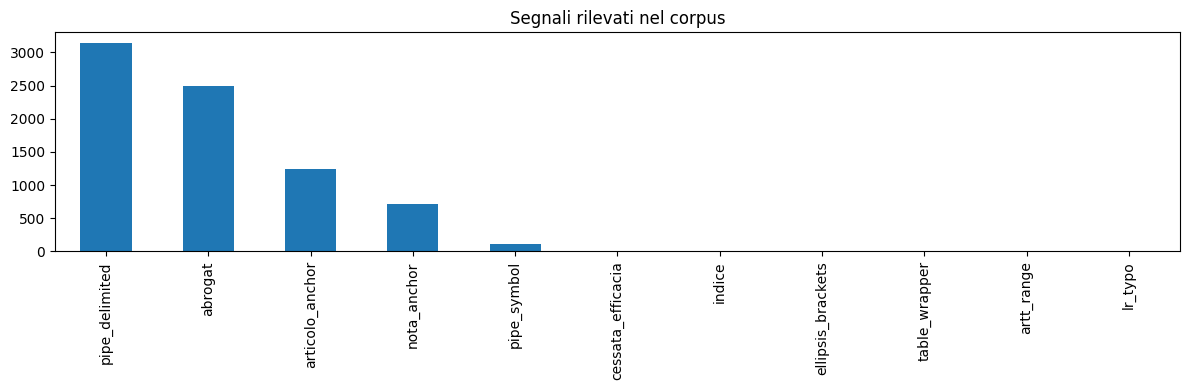

Figura salvata: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/data/laws_graph_pipeline/20260302_205923/step01_signal_counts.png


In [14]:
df_inventory = load_parquet_or_json_fallback(run_dir / 'step01_inventory.parquet')
signal_counts = json.loads((run_dir / 'step01_signal_counts.json').read_text(encoding='utf-8'))

display(df_inventory.head(10))
print('File censiti:', len(df_inventory))
print(json.dumps(signal_counts, ensure_ascii=False, indent=2))

fig_path = save_signal_counts_chart(signal_counts, run_dir)
print('Figura salvata:', fig_path)


### Step 2: Parsing strutturato (leggi, articoli, note)

Questa cella verifica il risultato del parsing strutturale non distruttivo.

Input:
- `step02_laws.parquet`
- `step02_articles.parquet`
- `step02_notes.parquet`

Output:
- cardinalita per entita;
- anteprima campi chiave (`law_id`, `article_id`, `note_id`).

Verifica attesa:
- presenza record nelle tre entita e chiavi stabili.


In [15]:
df_laws = load_parquet_or_json_fallback(run_dir / 'step02_laws.parquet')
df_articles = load_parquet_or_json_fallback(run_dir / 'step02_articles.parquet')
df_notes = load_parquet_or_json_fallback(run_dir / 'step02_notes.parquet')

print('laws:', len(df_laws), 'articles:', len(df_articles), 'notes:', len(df_notes))
display(df_laws[['law_id', 'law_title', 'source_file']].head(10))
display(df_articles[['law_id', 'article_id', 'article_label_norm', 'article_heading']].head(10))
display(df_notes[['law_id', 'note_id', 'note_kind']].head(10))


laws: 3145 articles: 17774 notes: 8345


,law_id,law_title,source_file
0,vda:lr:1950-10-10:1,"Legge regionale 10 ottobre 1950, n. 1 - Testo vigente",273_LR-10-ottobre-1950-n1.html
1,vda:lr:1951-09-28:1,"Legge regionale 28 settembre 1951, n. 1 - Testo vigente",275_LR-28-settembre-1951-n1.html
2,vda:lr:1951-09-28:2,"Legge regionale 28 settembre 1951, n. 2 - Testo vigente",276_LR-28-settembre-1951-n2.html
3,vda:lr:1951-09-28:3,"Legge regionale 28 settembre 1951, n. 3 - Testo vigente",277_LR-28-settembre-1951-n3.html
4,vda:lr:1951-09-28:4,"Legge regionale 28 settembre 1951, n. 4 - Testo vigente",278_LR-28-settembre-1951-n4.html
5,vda:lr:1952-03-31:1,"Legge regionale 31 marzo 1952, n. 1 - Testo vigente",279_LR-31-marzo-1952-n1.html
6,vda:lr:1952-05-10:2,"Legge regionale 10 maggio 1952, n. 2 - Testo vigente",281_LR-10-maggio-1952-n2.html
7,vda:lr:1952-09-10:3,"Legge regionale 10 settembre 1952, n. 3 - Testo vigente",282_LR-10-settembre-1952-n3.html
8,vda:lr:1952-11-20:4,"Legge regionale 20 novembre 1952, n. 4 - Testo vigente",283_LR-20-novembre-1952-n4.html
9,vda:lr:1953-05-15:1,"Legge regionale 15 maggio 1953, n. 1 - Testo vigente",284_LR-15-maggio-1953-n1.html


,law_id,article_id,article_label_norm,article_heading
0,vda:lr:1950-10-10:1,vda:lr:1950-10-10:1#art:unico,unico,NaN
1,vda:lr:1951-09-28:1,vda:lr:1951-09-28:1#art:unico,unico,NaN
2,vda:lr:1951-09-28:2,vda:lr:1951-09-28:2#art:unico,unico,NaN
3,vda:lr:1951-09-28:3,vda:lr:1951-09-28:3#art:unico,unico,NaN
4,vda:lr:1951-09-28:4,vda:lr:1951-09-28:4#art:unico,unico,NaN
5,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:1,1,NaN
6,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:2,2,NaN
7,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:3,3,NaN
8,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:4,4,NaN
9,vda:lr:1952-05-10:2,vda:lr:1952-05-10:2#art:1,1,(1)


,law_id,note_id,note_kind
0,vda:lr:1952-05-10:2,vda:lr:1952-05-10:2#note:nota_1,abrogated
1,vda:lr:1952-05-10:2,vda:lr:1952-05-10:2#note:nota_2,abrogated
2,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_1,modified
3,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_2,modified
4,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_3,modified
5,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_4,abrogated
6,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_5,modified
7,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_6,abrogated
8,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_7,modified
9,vda:lr:1956-05-31:1,vda:lr:1956-05-31:1#note:nota_8,abrogated


### Step 3: Classificazione status deterministica

Questa cella ispeziona la classificazione `status` (`current/past/unknown/index_or_empty`) e la relativa distribuzione.

Input:
- `step03_law_status.parquet`

Output:
- tabella status;
- grafico `step03_status_distribution.png`.

Verifica attesa:
- distribuzione leggibile e nessuna colonna critica mancante.


,law_id,status,status_confidence,status_evidence
0,vda:lr:1950-10-10:1,past,0.90,"[{'kind': 'ingest_status', 'snippet': 'abrogated', 'source_file': '273_LR-10-ottobre-1950-n1.html'}]"
1,vda:lr:1951-09-28:1,past,0.90,"[{'kind': 'ingest_status', 'snippet': 'abrogated', 'source_file': '275_LR-28-settembre-1951-n1.html'}]"
2,vda:lr:1951-09-28:2,unknown,0.65,"[{'kind': 'partial_abrogation', 'snippet': 'alle d'Aosta. (B.U. 19 novembre 1951). (Abrogata dall'art. 22 della L.R. 11 agosto 1975, n. 39 , ad eccezione delle norme concernent..."
3,vda:lr:1951-09-28:3,past,0.90,"[{'kind': 'ingest_status', 'snippet': 'abrogated', 'source_file': '277_LR-28-settembre-1951-n3.html'}]"
4,vda:lr:1951-09-28:4,past,0.90,"[{'kind': 'ingest_status', 'snippet': 'abrogated', 'source_file': '278_LR-28-settembre-1951-n4.html'}]"
5,vda:lr:1952-03-31:1,current,0.75,"[{'kind': 'ingest_status', 'snippet': 'in_force', 'source_file': '279_LR-31-marzo-1952-n1.html'}]"
6,vda:lr:1952-05-10:2,unknown,0.65,"[{'kind': 'partial_abrogation', 'snippet': 'Valle d'Aosta. (B.U. 30 giugno 1952). (Abrogata, ad eccezione delle norme dell'articolo 2, dall'art. 26 della L.R. 11 agosto 1976, n..."
7,vda:lr:1952-09-10:3,past,0.90,"[{'kind': 'ingest_status', 'snippet': 'abrogated', 'source_file': '282_LR-10-settembre-1952-n3.html'}]"
8,vda:lr:1952-11-20:4,past,0.90,"[{'kind': 'ingest_status', 'snippet': 'abrogated', 'source_file': '283_LR-20-novembre-1952-n4.html'}]"
9,vda:lr:1953-05-15:1,past,0.90,"[{'kind': 'ingest_status', 'snippet': 'abrogated', 'source_file': '284_LR-15-maggio-1953-n1.html'}]"


status
past       1895
current    1239
unknown      11
Name: count, dtype: int64


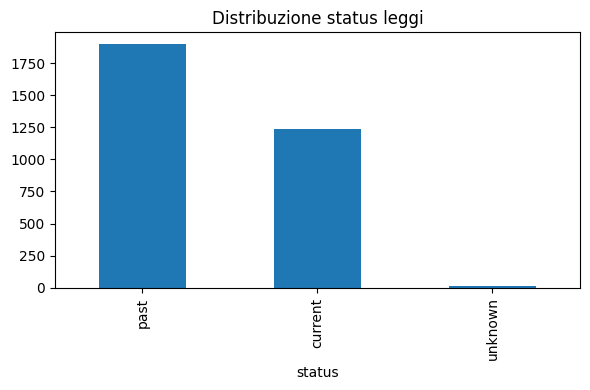

Figura salvata: /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/notebooks/data/laws_graph_pipeline/20260302_205923/step03_status_distribution.png


In [16]:
df_status = load_parquet_or_json_fallback(run_dir / 'step03_law_status.parquet')
display(df_status.head(10))

tab = df_status['status'].value_counts(dropna=False)
print(tab)
fig_path = save_status_distribution_chart(tab, run_dir)
print('Figura salvata:', fig_path)


## Sezione D - Ispezione Step 4-5 (relazioni ed eventi)

### Step 4: Relazioni raw vs clean
Questa cella confronta relazioni grezze e normalizzate, inclusa riduzione self-loop nel clean export.

Input:
- `step04_edges_raw.parquet`
- `step04_edges_clean.parquet`

Output:
- conteggi raw/clean;
- conteggio self-loop;
- distribuzione `relation_type` clean.

Verifica attesa:
- `self-loops clean` pari a 0 nel dataset finale.


In [17]:
df_edges_raw = load_parquet_or_json_fallback(run_dir / 'step04_edges_raw.parquet')
df_edges_clean = load_parquet_or_json_fallback(run_dir / 'step04_edges_clean.parquet')

print('edges raw:', len(df_edges_raw), 'edges clean:', len(df_edges_clean))
if 'is_self_loop' in df_edges_raw:
    print('self-loops raw:', int(df_edges_raw['is_self_loop'].fillna(False).sum()))
if 'is_self_loop' in df_edges_clean:
    print('self-loops clean:', int(df_edges_clean['is_self_loop'].fillna(False).sum()))

if 'relation_type' in df_edges_clean:
    rel = df_edges_clean['relation_type'].value_counts()
    display(rel)


edges raw: 41400 edges clean: 41400
self-loops raw: 0
self-loops clean: 0


relation_type
REFERENCES      14708
AMENDS           7130
ABROGATED_BY     6637
REPLACES         3984
REPLACED_BY      3337
MODIFIED_BY      3305
INSERTED_BY      1118
INSERTS           976
ABROGATES         205
Name: count, dtype: int64

### Step 5: Eventi normativi granulari

Questa cella mostra il layer eventi (abrogazioni, modifiche, sostituzioni, inserimenti) derivato dal grafo relazioni.

Input:
- `step05_events.parquet`

Output:
- numero eventi e anteprima record.

Verifica attesa:
- eventi non vuoti per corpus con modifiche normative.


In [18]:
df_events = load_parquet_or_json_fallback(run_dir / 'step05_events.parquet')
print('events:', len(df_events))
display(df_events.head(20))


events: 26692


,event_type,source_law_id,target_law_id,source_article_id,source_passage_id,target_article_label_norm,effective_date,evidence,confidence,source_file,event_id
0,AMEND,vda:lr:2024-12-17:29,vda:lr:2020-02-11:1,vda:lr:2024-12-17:29#art:58,vda:lr:2024-12-17:29#art:58#p:intro,NaN,2020-02-11,"(Iniziative e manifestazioni organizzate in Valle d'Aosta a favore degli emigrati valdostani all'estero. Modificazioni alla legge regionale 11 febbraio 2020, n.1 )",0.4,11241_LR-17-dicembre-2024-n29.html,000126982a681da2ab46356520447515da0220ef6e47c10fc81e97878da21565
1,AMEND,vda:lr:1997-12-19:45,vda:lr:2005-01-20:1,NaN,NaN,7,2005-01-20,"La lettera c) del comma 1 dell'art. 7 era già stata modificata dall'art. 15, comma 1, lettera c), della L.R. 20 gennaio 2005, n. 1 , nel modo seguente:",0.7,2455_LR-19-dicembre-1997-n45.html,00014c3ca67edb7622cef4647a04e08b7822bee8169f022454f490d35e66211b
2,REPEAL,vda:lr:1980-12-29:66,vda:lr:1971-08-03:10,vda:lr:1980-12-29:66#art:unico,vda:lr:1980-12-29:66#art:unico#p:intro,4,1980-12-29,"Legge regionale 29 dicembre 1980, n. 66 - Testo vigente\nLegge regionale 29 dicembre 1980, n. 66\nAumento, per l'anno 1980, della spesa per l'applicazione della legge regionale...",0.7,853_LR-29-dicembre-1980-n66.html,00020487ca1de8fdcd5434b4a1fc37d9cf99ce9cf01ffcb2e4419d43c0ab7df6
3,REPEAL,vda:lr:2002-05-20:5,vda:lr:2002-12-11:25,vda:lr:2002-05-20:5#art:32,vda:lr:2002-05-20:5#art:32#p:c5,32,2002-12-11,"Il comma 2 dell'art. 32 era stato abrogato dall'art. 41, comma 2, della L.R. 11 dicembre 2002, n. 25 .",0.7,2664_LR-20-maggio-2002-n5.html,0006e8cc6e6ca319e9b42450007d3300c143af50d0a5e98164a65cdcfdfaeb0d
4,REPEAL,vda:lr:1998-04-06:11,vda:lr:2023-05-15:5,NaN,NaN,NaN,2023-05-15,"( 82e ) Comma abrogato dalla lettera c) del comma 1 dell'articolo 21 della L.R. 15 maggio 2023, n. 5 .",0.9,2467_LR-6-aprile-1998-n11.html,00077bace330e57686657ee7893324ed23d45571c03f8910b9bd1afb4d836603
5,REPLACE,vda:lr:2018-12-24:12,vda:lr:2015-05-25:13,vda:lr:2018-12-24:12#art:25,vda:lr:2018-12-24:12#art:25#p:c1,NaN,2015-05-25,"1. La lettera a) del comma 5 dell'articolo 27 della legge regionale 25 maggio 2015, n. 13 (Legge europea regionale 2015), è sostituita dalla seguente:",0.6,8982_LR-24-dicembre-2018-n12.html,000c11ef362544fb9326bc1a595bcec695c023c9b4006e675818f1f2018a07ac
6,INSERT,vda:lr:2000-08-04:22,vda:lr:1999-08-02:20,vda:lr:2000-08-04:22#art:2,vda:lr:2000-08-04:22#art:2#p:intro,11bis,1999-08-02,"( 2 ) Inserisce l'art. 11bis alla L.R. 2 agosto 1999, n. 20 .",0.4,2597_LR-4-agosto-2000-n22.html,000e39794e172b15eb2a23b2e22b88035c7fca4948e4eb3dd705d40ded968546
7,AMEND,vda:lr:2011-12-13:30,vda:lr:2010-12-10:40,vda:lr:2011-12-13:30#art:45,vda:lr:2011-12-13:30#art:45#p:c1,NaN,2009-06-17,"1. Il finanziamento al Comune di Aosta per le finalità di cui all'articolo 24 della legge regionale 17 giugno 2009, n. 15 (Assestamento del bilancio di previsione per l'anno fi...",0.4,6741_LR-13-dicembre-2011-n30.html,000e433664f8744b21fbe5300bfad60ec5a6fa16aa0d938e6cb8b4a364f72b04
8,REPLACE,vda:lr:1998-04-06:11,vda:lr:2012-06-12:17,NaN,NaN,17,2012-06-12,"( 40 ) Comma così sostituito dall'art. 17, comma 3, della L.R. 12 giugno 2012, n. 17 .",0.7,2467_LR-6-aprile-1998-n11.html,000e6b5880dda6f81da084c5c8771efdb2577fb83d0365115df38816d529daba
9,REPLACE,vda:lr:1999-09-08:28,vda:lr:2009-08-04:29,NaN,NaN,9,2009-08-04,"( 18 ) Comma così sostituito dall'art. 9, comma 1, della L.R. 4 agosto 2009, n. 29 .",0.7,2553_LR-8-settembre-1999-n28.html,000fbb3d6387b1fb6af28da7e3526f3264ce9125b86b1e680fd0cb9f6a4cb853


## Sezione E - Ispezione Step 6-7 (views ed export)

### Step 6: Chunks con index views
Questa cella controlla il tagging retrieval-oriented:
- tutti i chunk in `historical`;
- subset deterministico in `current`.

Input:
- `step06_chunks_with_views.parquet`

Output:
- cardinalita `historical` vs `current`;
- anteprima metadati chunk.

Verifica attesa:
- colonna `index_views` presente e valorizzata.


In [19]:
df_chunks = load_parquet_or_json_fallback(run_dir / 'step06_chunks_with_views.parquet')
print('chunks:', len(df_chunks))

n_historical = len(df_chunks)
n_current = int(df_chunks['index_views'].apply(has_current).sum()) if 'index_views' in df_chunks else 0
print('historical:', n_historical, 'current:', n_current)
display(df_chunks[['chunk_id', 'law_id', 'article_id', 'index_views']].head(20))


chunks: 74517
historical: 74517 current: 64818


,chunk_id,law_id,article_id,index_views
0,vda:lr:1950-10-10:1#art:unico#p:intro#chunk:0,vda:lr:1950-10-10:1,vda:lr:1950-10-10:1#art:unico,[historical]
1,vda:lr:1951-09-28:1#art:unico#p:intro#chunk:0,vda:lr:1951-09-28:1,vda:lr:1951-09-28:1#art:unico,[historical]
2,vda:lr:1951-09-28:2#art:unico#p:intro#chunk:0,vda:lr:1951-09-28:2,vda:lr:1951-09-28:2#art:unico,[historical]
3,vda:lr:1951-09-28:3#art:unico#p:intro#chunk:0,vda:lr:1951-09-28:3,vda:lr:1951-09-28:3#art:unico,[historical]
4,vda:lr:1951-09-28:4#art:unico#p:intro#chunk:0,vda:lr:1951-09-28:4,vda:lr:1951-09-28:4#art:unico,[historical]
5,vda:lr:1952-03-31:1#art:1#p:intro#chunk:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:1,"[historical, current]"
6,vda:lr:1952-03-31:1#art:2#p:intro#chunk:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:2,"[historical, current]"
7,vda:lr:1952-03-31:1#art:3#p:intro#chunk:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:3,"[historical, current]"
8,vda:lr:1952-03-31:1#art:4#p:intro#chunk:0,vda:lr:1952-03-31:1,vda:lr:1952-03-31:1#art:4,"[historical, current]"
9,vda:lr:1952-05-10:2#art:10#p:intro#chunk:0,vda:lr:1952-05-10:2,vda:lr:1952-05-10:2#art:10,[historical]


### Step 7: Verifica export dataset clean

Questa cella verifica la presenza dei file pubblici in `data/laws_dataset_clean` e stampa il manifest finale.

Input:
- output directory da `manifest['output_dir']`.

Output:
- check `OK/MISSING` su file obbligatori;
- estratto `manifest.json`.

Verifica attesa:
- tutti i file richiesti presenti.


In [20]:
out_dir = Path(manifest['output_dir'])
for name in ['laws.jsonl', 'articles.jsonl', 'notes.jsonl', 'edges.jsonl', 'events.jsonl', 'chunks.jsonl', 'manifest.json']:
    p = out_dir / name
    print(name, 'OK' if p.exists() else 'MISSING', p)

final_manifest = json.loads((out_dir / 'manifest.json').read_text(encoding='utf-8'))
print(json.dumps(final_manifest, ensure_ascii=False, indent=2)[:5000])


laws.jsonl OK /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/laws.jsonl
articles.jsonl OK /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/articles.jsonl
notes.jsonl OK /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/notes.jsonl
edges.jsonl OK /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/edges.jsonl
events.jsonl OK /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/events.jsonl
chunks.jsonl OK /Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/chunks.jsonl
manifest.json OK /Users/paolo.bonicco/Librar

## Sezione F - Quality dashboard finale (Step 8)

Questa cella legge il report markdown con metriche e gate QA finali del run.

Input:
- `step08_quality_report.md`

Output:
- report completo stampato a schermo.

Verifica attesa:
- evidenza chiara di pass/fail dei gate qualita.


In [21]:
quality_md = run_dir / 'step08_quality_report.md'
print(quality_md.read_text(encoding='utf-8'))


# Step 08 - Quality Report

- Ready to embedding: **True**
- Timestamp (UTC): `2026-03-02T20:59:42Z`

## Gate Results
- `duplicate_article_id_passage_id_chunk_id_zero`: **True**
- `self_loops_edges_zero_in_clean`: **True**
- `unresolved_refs_not_worse`: **True**
- `abrogated_by_coverage_ge_99`: **True**

## Counts
- laws: 3145
- articles: 17774
- passages: 74436
- notes: 8345
- edges_raw: 41400
- edges_clean: 41400
- events: 26692
- chunks: 74517

## Key Metrics
- duplicate article_id: 0
- duplicate passage_id: 0
- duplicate chunk_id: 0
- self loops raw: 0
- self loops clean: 0
- unresolved refs baseline/new: 161 / 155
- ABROGATED_BY coverage: 1.0000



## Sezione G - Passaggio al notebook 04 (gate di handoff)

Questa sezione formalizza il contratto dati verso `04_qdrant_indexing_pipeline.ipynb`.

Ruoli distinti:
- **03:** costruisce dataset legale strutturato e metadata normativi.
- **04:** valida dataset, rifinisce chunk per embedding e indicizza su Qdrant.

La cella seguente controlla:
- presenza file obbligatori in `data/laws_dataset_clean`;
- flag `ready_to_embedding` dal manifest;
- presenza campi critici su campione di `chunks.jsonl`.

Output atteso:
- tabella `OK/MISSING`;
- esito finale: dataset pronto/non pronto per notebook 04.


In [22]:
dataset_dir_04 = Path(manifest['output_dir'])
validation_04 = validate_handoff_for_notebook_04(dataset_dir_04, chunk_sample_size=200)

display(validation_04['contract_df'])
print('manifest.ready_to_embedding:', validation_04['ready_to_embedding'])
print('chunk rows controllate (sample):', validation_04['checked_chunk_rows'])
print('campi chunk mancanti (sample):', validation_04['missing_chunk_fields'])

if validation_04['handoff_ok']:
    print('Handoff OK: dataset pronto per 04_qdrant_indexing_pipeline.ipynb')
else:
    print('Handoff NON pronto: verificare file mancanti, ready_to_embedding o campi chunk.')


,file,exists,path
0,manifest.json,True,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/manifest.json
1,laws.jsonl,True,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/laws.jsonl
2,articles.jsonl,True,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/articles.jsonl
3,notes.jsonl,True,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/notes.jsonl
4,edges.jsonl,True,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/edges.jsonl
5,events.jsonl,True,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/events.jsonl
6,chunks.jsonl,True,/Users/paolo.bonicco/Library/Mobile Documents/com~apple~CloudDocs/Università/Tesi/agentic-legal-rag-suite/data/laws_dataset_clean/chunks.jsonl


manifest.ready_to_embedding: True
chunk rows controllate (sample): 200
campi chunk mancanti (sample): []
Handoff OK: dataset pronto per 04_qdrant_indexing_pipeline.ipynb


## Sezione H - Come eseguire e troubleshooting rapido

### Come eseguire (3 passi)
1. Esegui tutte le celle del notebook 03 in ordine.
2. Verifica in **Sezione G** che l'handoff sia `OK`.
3. Passa a `notebooks/04_qdrant_indexing_pipeline.ipynb` per refinement/indexing.

### Se qualcosa fallisce
- **Root non trovata:** apri il notebook dentro il repository e riesegui la Sezione A.
- **Fallback parquet/jsonl:** se i parquet non sono leggibili, la utility usa JSONL fallback; controlla comunque i conteggi.
- **File output mancanti:** riesegui la Sezione B e poi Sezione E/G per validare export e contratto.
